In [1]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))
warnings.filterwarnings("ignore")


import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_catboost_tuning, run_lgbm_tuning, run_lr_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [California](https://www.openml.org/search?type=data&status=active&id=44090)

In [2]:
dataset_id = 44090
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
metrics_lr = bootstrap_metrics(y_test, y_pred_lr, y_prob_lr)

[I 2025-04-21 16:35:46,893] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-21 16:35:46,905] Trial 0 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 1e-05}. Best is trial 0 with value: 0.5.
[I 2025-04-21 16:35:46,954] Trial 1 finished with value: 0.9137305825971996 and parameters: {'penalty': 'l2', 'C': 100}. Best is trial 1 with value: 0.9137305825971996.
[I 2025-04-21 16:35:46,992] Trial 2 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.0001}. Best is trial 1 with value: 0.9137305825971996.
[I 2025-04-21 16:35:47,014] Trial 3 finished with value: 0.8657401147767563 and parameters: {'penalty': 'l2', 'C': 0.001}. Best is trial 1 with value: 0.9137305825971996.
[I 2025-04-21 16:35:47,112] Trial 4 finished with value: 0.9137333994351301 and parameters: {'penalty': 'l1', 'C': 100}. Best is trial 4 with value: 0.9137333994351301.
[I 2025-04-21 16:35:47,130] Trial 5 finished with value: 0.8382318144943213 and parameters:

In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb  = model_cb.predict(X_test)
y_prob_cb  = model_cb.predict_proba(X_test)[:, 1]
metrics_cb = bootstrap_metrics(y_test, y_pred_cb, y_prob_cb)

[I 2025-04-21 16:35:52,102] A new study created in memory with name: catboost_optimization
[I 2025-04-21 16:35:54,695] Trial 0 finished with value: 0.9561897196682891 and parameters: {'depth': 4, 'learning_rate': 0.01, 'l2_leaf_reg': 0.001}. Best is trial 0 with value: 0.9561897196682891.
[I 2025-04-21 16:35:57,946] Trial 1 finished with value: 0.9252270371371913 and parameters: {'depth': 6, 'learning_rate': 0.001, 'l2_leaf_reg': 0.1}. Best is trial 0 with value: 0.9561897196682891.
[I 2025-04-21 16:36:02,598] Trial 2 finished with value: 0.9382051484285799 and parameters: {'depth': 8, 'learning_rate': 0.001, 'l2_leaf_reg': 0.01}. Best is trial 0 with value: 0.9561897196682891.
[I 2025-04-21 16:36:05,802] Trial 3 finished with value: 0.9653942070789014 and parameters: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 0.001}. Best is trial 3 with value: 0.9653942070789014.
[I 2025-04-21 16:36:14,617] Trial 4 finished with value: 0.9466115317589086 and parameters: {'depth': 10, 'learning

In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
y_prob_lgbm = model_lgbm.predict_proba(X_test)[:, 1]
metrics_lgbm = bootstrap_metrics(y_test, y_pred_lgbm, y_prob_lgbm)

[I 2025-04-21 16:37:17,281] A new study created in memory with name: lightgbm_optimization
[I 2025-04-21 16:37:53,782] Trial 0 finished with value: 0.9690298059010877 and parameters: {'num_leaves': 4096, 'reg_alpha': 1e-07, 'reg_lambda': 1e-05, 'learning_rate': 0.01}. Best is trial 0 with value: 0.9690298059010877.
[I 2025-04-21 16:37:54,150] Trial 1 finished with value: 0.9095729298119104 and parameters: {'num_leaves': 2, 'reg_alpha': 0.0001, 'reg_lambda': 0.1, 'learning_rate': 0.01}. Best is trial 0 with value: 0.9690298059010877.
[I 2025-04-21 16:38:33,154] Trial 2 finished with value: 0.9692129003665646 and parameters: {'num_leaves': 2048, 'reg_alpha': 1e-08, 'reg_lambda': 1e-06, 'learning_rate': 0.01}. Best is trial 2 with value: 0.9692129003665646.
[I 2025-04-21 16:38:59,151] Trial 3 finished with value: 0.97102412715582 and parameters: {'num_leaves': 1024, 'reg_alpha': 1e-06, 'reg_lambda': 1e-06, 'learning_rate': 0.03}. Best is trial 3 with value: 0.97102412715582.
[I 2025-04-21

In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


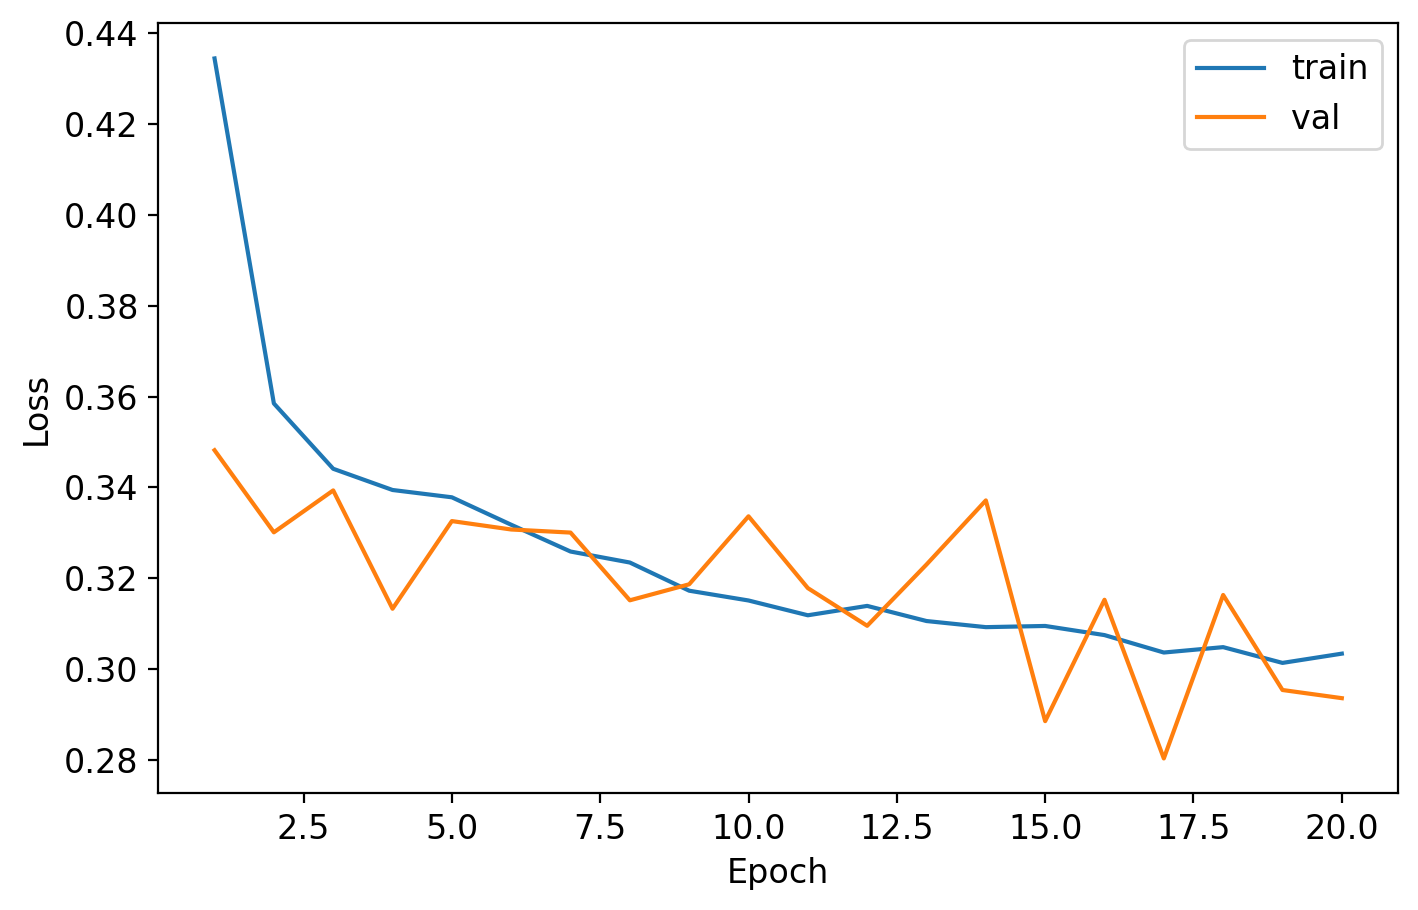

Epoch 20: train loss = 0.3034; valid loss = 0.2936


In [11]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 20, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
metrics_nn = bootstrap_metrics(y_true, y_pred, y_prob)

In [13]:
res = pd.DataFrame([{"model": "Logistic regression"} | metrics_lr, {"model": "CatBoost"} | metrics_cb, {"model": "LightGBM"} | metrics_lgbm, {"model": "TABMLP"} | metrics_nn])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,Logistic regression,0.9104±0.0061,0.8289±0.0092,0.8278±0.0085,0.8237±0.0116,0.8343±0.0120
1,CatBoost,0.9673±0.0033,0.9019±0.0069,0.9021±0.0066,0.9036±0.0091,0.9004±0.0097
2,LightGBM,0.9659±0.0033,0.9037±0.0069,0.9040±0.0065,0.9071±0.0088,0.9003±0.0095
3,TABMLP,0.9316±0.0050,0.8494±0.0082,0.8481±0.0077,0.8422±0.0107,0.8570±0.0110
